In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')
import re
from math import radians, sin, cos, sqrt, atan2
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import pandas as pd

# 读取两个Excel文件
try:
    # 读取训练集数据
    train_df = pd.read_excel(r"D:\desktop\Midterm\ruc_Class25Q2_train_rent.xlsx")
    print("训练集数据读取成功！")
    print(f"训练集形状: {train_df.shape}")
    
    # 读取测试集数据
    test_df = pd.read_excel(r"D:\desktop\Midterm\ruc_Class25Q2_test_rent.xlsx")
    print("测试集数据读取成功！")
    print(f"测试集形状: {test_df.shape}")
    
except FileNotFoundError as e:
    print(f"文件未找到: {e}")
except Exception as e:
    print(f"读取文件时出错: {e}")

# 查看数据基本信息
print("\n=== 训练集基本信息 ===")
print(f"行数: {train_df.shape[0]}, 列数: {train_df.shape[1]}")
print(train_df.columns.tolist())

print("\n=== 测试集基本信息 ===")
print(f"行数: {test_df.shape[0]}, 列数: {test_df.shape[1]}")
print(test_df.columns.tolist())

训练集数据读取成功！
训练集形状: (98899, 46)
测试集数据读取成功！
测试集形状: (9773, 46)

=== 训练集基本信息 ===
行数: 98899, 列数: 46
['城市', '户型', '装修', 'Price', '楼层', '面积', '朝向', '交易时间', '付款方式', '租赁方式', '电梯', '车位', '用水', '用电', '燃气', '采暖', '租期', '配套设施', 'lon', 'lat', '年份', '区县', '板块', '环线位置', '物业类别', '建筑年代', '开发商', '房屋总数', '楼栋总数', '物业公司', '绿化率', '容积率', '物业费', '建筑结构', '物业办公电话', '产权描述', '供水', '供暖', '供电', '燃气费', '供热费', '停车位', '停车费用', 'coord_x', 'coord_y', '客户反馈']

=== 测试集基本信息 ===
行数: 9773, 列数: 46
['ID', '城市', '户型', '装修', '楼层', '面积', '朝向', '交易时间', '付款方式', '租赁方式', '电梯', '车位', '用水', '用电', '燃气', '采暖', '租期', '配套设施', 'lon', 'lat', '年份', '区县', '板块', '环线位置', '物业类别', '建筑年代', '开发商', '房屋总数', '楼栋总数', '物业公司', '绿化率', '容积率', '物业费', '建筑结构', '物业办公电话', '产权描述', '供水', '供暖', '供电', '燃气费', '供热费', '停车位', '停车费用', 'coord_x', 'coord_y', '客户反馈']


In [3]:
# 只对训练集的价格取自然对数
train_df['lnPrice'] = np.log(train_df['Price'])

print("训练集价格取对数完成!")

# 查看处理前后的统计信息
print("\n价格变量统计信息对比:")
print(f"原始价格 - 均值: {train_df['Price'].mean():.2f}, 标准差: {train_df['Price'].std():.2f}")
print(f"对数价格 - 均值: {train_df['lnPrice'].mean():.2f}, 标准差: {train_df['lnPrice'].std():.2f}")

# 数据质量检查
print(f"\n数据质量检查:")
print(f"lnPrice缺失值: {train_df['lnPrice'].isnull().sum()}")
print(f"lnPrice无限值: {np.isinf(train_df['lnPrice']).sum()}")

# 检查非正价格
negative_prices = train_df[train_df['Price'] <= 0]
if len(negative_prices) > 0:
    print(f"警告: 发现 {len(negative_prices)} 个非正价格")

训练集价格取对数完成!

价格变量统计信息对比:
原始价格 - 均值: 582908.98, 标准差: 621842.40
对数价格 - 均值: 12.96, 标准差: 0.76

数据质量检查:
lnPrice缺失值: 0
lnPrice无限值: 0


In [4]:
# 2.1 装修变量处理（两个数据集）
# 2.1.1 检查装修变量分布
print("=== 训练集装修变量分布 ===")
print(train_df['装修'].value_counts())
print("\n=== 测试集装修变量分布 ===")
print(test_df['装修'].value_counts())

# 2.1.2 变量类型转换
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    df['decoration'] = df['装修'].astype(str).str.contains('精装修').astype(int)
    print(f"\n{name}转换后分布:")
    print(df['decoration'].value_counts())

=== 训练集装修变量分布 ===
装修
精装修    25410
Name: count, dtype: int64

=== 测试集装修变量分布 ===
装修
精装修    7091
Name: count, dtype: int64

训练集转换后分布:
decoration
0    73489
1    25410
Name: count, dtype: int64

测试集转换后分布:
decoration
1    7091
0    2682
Name: count, dtype: int64


In [5]:
# 2.2 楼层变量处理（两个数据集）
def process_floor_features(df):
    df = df.copy()
    
    # 提取总楼层
    df['总楼层'] = df['楼层'].str.extract(r'(\d+)层').astype(float)
    
    # 计算准确楼层
    def get_actual_floor(floor_str, total_floor):
        if pd.isna(total_floor):
            return np.nan
        if '地下室' in floor_str:
            return -1
        elif '中楼层' in floor_str:
            return total_floor // 2
        elif '高楼层' in floor_str:
            return int(total_floor * 0.75)
        elif '低楼层' in floor_str:
            return int(total_floor * 0.25)
        else:
            return np.nan
    
    df['准确楼层'] = df.apply(lambda x: get_actual_floor(x['楼层'], x['总楼层']), axis=1)
    return df

# 应用楼层处理
train_df = process_floor_features(train_df)
test_df = process_floor_features(test_df)

print("楼层变量处理完成")

# 打印统计信息
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}楼层变量统计:")
    print(f"总楼层 - 有效值: {df['总楼层'].notna().sum()}, 缺失值: {df['总楼层'].isna().sum()}")
    print(f"准确楼层 - 有效值: {df['准确楼层'].notna().sum()}, 缺失值: {df['准确楼层'].isna().sum()}")

楼层变量处理完成

训练集楼层变量统计:
总楼层 - 有效值: 98634, 缺失值: 265
准确楼层 - 有效值: 89448, 缺失值: 9451

测试集楼层变量统计:
总楼层 - 有效值: 9733, 缺失值: 40
准确楼层 - 有效值: 8289, 缺失值: 1484


In [6]:
# 2.3 面积变量处理（两个数据集）
for df in [train_df, test_df]:
    df['area'] = df['面积'].str.replace('㎡', '').astype(float)

print("面积提取完成!")

面积提取完成!


In [7]:
# 2.4 户型变量处理（两个数据集）
def extract_room_features(df):
    df = df.copy()
    
    # 提取室、厅、卫数量
    df['室'] = df['户型'].str.extract(r'(\d+)室').fillna(0).astype(int)
    df['厅'] = df['户型'].str.extract(r'(\d+)厅').fillna(0).astype(int)
    df['卫'] = df['户型'].str.extract(r'(\d+)卫').fillna(0).astype(int)
    
    return df

# 应用户型处理
train_df = extract_room_features(train_df)
test_df = extract_room_features(test_df)

print("户型变量处理完成")

# 打印统计信息
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}户型变量统计:")
    print(f"室 - 均值: {df['室'].mean():.2f}, 标准差: {df['室'].std():.2f}")
    print(f"厅 - 均值: {df['厅'].mean():.2f}, 标准差: {df['厅'].std():.2f}")
    print(f"卫 - 均值: {df['卫'].mean():.2f}, 标准差: {df['卫'].std():.2f}")

户型变量处理完成

训练集户型变量统计:
室 - 均值: 2.14, 标准差: 1.08
厅 - 均值: 1.29, 标准差: 0.66
卫 - 均值: 0.45, 标准差: 0.69

测试集户型变量统计:
室 - 均值: 2.31, 标准差: 1.06
厅 - 均值: 1.36, 标准差: 0.61
卫 - 均值: 1.28, 标准差: 0.55


In [8]:
# 2.5 朝向变量处理（两个数据集）
# 2.5.1 检查朝向分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}朝向分布:")
    print(df['朝向'].value_counts())
    print(f"朝向缺失值: {df['朝向'].isna().sum()}")

# 2.5.2 创建朝向哑变量
def create_orientation_dummies(df):
    df = df.copy()
    
    # 删除已存在的朝向哑变量列
    orientation_cols = [col for col in df.columns if col in ['south_dummy', 'north_south_dummy']]
    if orientation_cols:
        df = df.drop(columns=orientation_cols)
    
    # 初始化哑变量
    df['south_dummy'] = np.nan
    df['north_south_dummy'] = np.nan
    
    # 对非空朝向进行处理
    valid_mask = df['朝向'].notna()
    orientation_str = df.loc[valid_mask, '朝向'].astype(str)
    
    # 朝南哑变量
    south_mask = orientation_str.str.contains('南')
    df.loc[valid_mask & south_mask, 'south_dummy'] = 1
    df.loc[valid_mask & ~south_mask, 'south_dummy'] = 0
    
    # 南北通透哑变量
    north_south_mask = orientation_str.str.contains('南') & orientation_str.str.contains('北')
    df.loc[valid_mask & north_south_mask, 'north_south_dummy'] = 1
    df.loc[valid_mask & ~north_south_mask, 'north_south_dummy'] = 0
    
    return df

# 应用朝向处理
train_df = create_orientation_dummies(train_df)
test_df = create_orientation_dummies(test_df)

print("\n朝向哑变量创建完成")

# 打印哑变量分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}朝向哑变量分布:")
    print(f"朝南: {(df['south_dummy'] == 1).sum()}, 不朝南: {(df['south_dummy'] == 0).sum()}, 缺失: {df['south_dummy'].isna().sum()}")
    print(f"南北通透: {(df['north_south_dummy'] == 1).sum()}, 非南北通透: {(df['north_south_dummy'] == 0).sum()}, 缺失: {df['north_south_dummy'].isna().sum()}")


训练集朝向分布:
朝向
南             44486
南 北           16776
东南            10307
北              6587
东              6372
              ...  
东 西北 东北           1
东 东南 北 东北         1
东 东南 南 北          1
东 东南 西南 西         1
东南 南 西南 东北        1
Name: count, Length: 91, dtype: int64
朝向缺失值: 5

测试集朝向分布:
朝向
南               4651
南 北             1759
东南               892
北                628
东                594
西南               301
西                265
东北               135
西北               116
东 西               88
东南 南              64
东 南               39
东 东南              29
南 西南              28
东 北               16
南 西               15
东南 北              13
南 西 北             13
东南 西南             12
西 北               11
西南 北              11
南 西北              10
东 南 北             10
东南 西北              9
西南 西               7
北 东北               6
东 东北               4
西南 东北              3
东南 东北              3
西 西北               3
东南 南 北             3
东南 南 西南            3
西北 北               3
东 东南 南        

In [9]:
# 2.6 付款方式处理（两个数据集）
# 2.6.1 检查付款方式分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}付款方式分布:")
    print(df['付款方式'].value_counts())

# 2.6.2 异常值处理和创建哑变量
def process_payment_method(df):
    df = df.copy()
    
    # 将包含链接的付款方式设为NaN
    link_mask = df['付款方式'].str.contains('http', na=False)
    df.loc[link_mask, '付款方式'] = np.nan
    print(f"已将 {link_mask.sum()} 个包含链接的付款方式设为空值")
    
    # 删除已存在的付款方式哑变量列
    payment_cols = [col for col in df.columns if col.startswith('pay_')]
    if payment_cols:
        df = df.drop(columns=payment_cols)
    
    # 创建付款方式映射和哑变量
    payment_mapping = {
        '季付价': 'quarterly',
        '月付价': 'monthly', 
        '半年付价': 'semi_annual',
        '年付价': 'annual',
        '双月付价': 'bi_monthly'
    }
    
    df['payment_method_en'] = df['付款方式'].map(payment_mapping)
    payment_dummies = pd.get_dummies(df['payment_method_en'], prefix='pay').astype(int)
    
    # 保留缺失值
    if df['付款方式'].isna().any():
        na_mask = df['付款方式'].isna()
        for col in payment_dummies.columns:
            payment_dummies.loc[na_mask, col] = np.nan
    
    df = pd.concat([df, payment_dummies], axis=1)
    df = df.drop('payment_method_en', axis=1)
    
    return df

# 应用付款方式处理
train_df = process_payment_method(train_df)
test_df = process_payment_method(test_df)

print("\n付款方式哑变量创建完成")

# 打印哑变量分布
payment_cols = [col for col in train_df.columns if col.startswith('pay_')]
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}付款方式哑变量分布:")
    for col in payment_cols:
        valid_count = df[col].notna().sum()
        true_count = (df[col] == 1).sum()
        na_count = df[col].isna().sum()
        print(f"{col}: {true_count}个为1, {valid_count-true_count}个为0, {na_count}个缺失")


训练集付款方式分布:
付款方式
季付价                               54530
月付价                               20955
半年付价                               4194
年付价                                 748
双月付价                                 44
https://img.ljcdn.com/usercent        3
https://image1.ljcdn.com/rent-        2
Name: count, dtype: int64

测试集付款方式分布:
付款方式
季付价     5325
月付价     1726
半年付价     284
年付价       49
双月付价       2
Name: count, dtype: int64
已将 5 个包含链接的付款方式设为空值
已将 0 个包含链接的付款方式设为空值

付款方式哑变量创建完成

训练集付款方式哑变量分布:
pay_annual: 748个为1, 79723个为0, 18428个缺失
pay_bi_monthly: 44个为1, 80427个为0, 18428个缺失
pay_monthly: 20955个为1, 59516个为0, 18428个缺失
pay_quarterly: 54530个为1, 25941个为0, 18428个缺失
pay_semi_annual: 4194个为1, 76277个为0, 18428个缺失

测试集付款方式哑变量分布:
pay_annual: 49个为1, 7337个为0, 2387个缺失
pay_bi_monthly: 2个为1, 7384个为0, 2387个缺失
pay_monthly: 1726个为1, 5660个为0, 2387个缺失
pay_quarterly: 5325个为1, 2061个为0, 2387个缺失
pay_semi_annual: 284个为1, 7102个为0, 2387个缺失


In [10]:
# 2.7 租赁方式处理（两个数据集）
# 2.7.1 检查租赁方式分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}租赁方式分布:")
    print(df['租赁方式'].value_counts())
    print(f"缺失值: {df['租赁方式'].isna().sum()}")

# 2.7.2 创建租赁方式哑变量
def create_rent_type_dummy(df):
    df = df.copy()
    
    # 删除已存在的租赁方式哑变量列
    if 'rent_type_shared' in df.columns:
        df = df.drop(columns=['rent_type_shared'])
    
    # 创建哑变量：合租=1，整租=0，缺失值保留为NaN
    df['rent_type_shared'] = df['租赁方式'].map({'整租': 0, '合租': 1})
    
    return df

# 应用租赁方式处理
train_df = create_rent_type_dummy(train_df)
test_df = create_rent_type_dummy(test_df)

print("\n租赁方式哑变量创建完成")

# 打印哑变量分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}租赁方式哑变量分布:")
    print(f"整租: {(df['rent_type_shared'] == 0).sum()}, 合租: {(df['rent_type_shared'] == 1).sum()}, 缺失: {df['rent_type_shared'].isna().sum()}")


训练集租赁方式分布:
租赁方式
整租    93009
合租     5890
Name: count, dtype: int64
缺失值: 0

测试集租赁方式分布:
租赁方式
整租    9128
合租     645
Name: count, dtype: int64
缺失值: 0

租赁方式哑变量创建完成

训练集租赁方式哑变量分布:
整租: 93009, 合租: 5890, 缺失: 0

测试集租赁方式哑变量分布:
整租: 9128, 合租: 645, 缺失: 0


In [11]:
# 2.8 电梯处理（两个数据集）
# 2.8.1 检查电梯分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}电梯分布:")
    print(df['电梯'].value_counts())
    print(f"缺失值: {df['电梯'].isna().sum()}")

# 2.8.2 创建电梯哑变量
def create_elevator_dummy(df):
    df = df.copy()
    
    # 删除已存在的电梯哑变量列
    if 'elevator_yes' in df.columns:
        df = df.drop(columns=['elevator_yes'])
    
    # 创建哑变量：有电梯=1，无电梯=0，缺失值保留为NaN
    df['elevator_yes'] = df['电梯'].map({'无': 0, '有': 1})
    
    return df

# 应用电梯处理
train_df = create_elevator_dummy(train_df)
test_df = create_elevator_dummy(test_df)

print("\n电梯哑变量创建完成")

# 打印哑变量分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}电梯哑变量分布:")
    print(f"无电梯: {(df['elevator_yes'] == 0).sum()}, 有电梯: {(df['elevator_yes'] == 1).sum()}, 缺失: {df['elevator_yes'].isna().sum()}")


训练集电梯分布:
电梯
有    69234
无    29661
Name: count, dtype: int64
缺失值: 4

测试集电梯分布:
电梯
有    6496
无    3277
Name: count, dtype: int64
缺失值: 0

电梯哑变量创建完成

训练集电梯哑变量分布:
无电梯: 29661, 有电梯: 69234, 缺失: 4

测试集电梯哑变量分布:
无电梯: 3277, 有电梯: 6496, 缺失: 0


In [12]:
# 2.9 用水用电燃气处理（两个数据集）
# 2.9.1 检查分布和缺失值
utility_cols = ['用水', '用电', '燃气', '供水', '供电', '燃气费']
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}公用设施分布:")
    for col in utility_cols:
        if col in df.columns:
            print(f"{col}: {df[col].isna().sum()}个缺失值")

# 2.9.2 创建用水、用电、燃气哑变量
def create_utility_dummies(df):
    df = df.copy()
    
    # 删除已存在的哑变量列
    utility_dummy_cols = ['water_civil', 'water_commercial', 'electricity_civil', 
                         'electricity_commercial', 'gas_yes']
    for col in utility_dummy_cols:
        if col in df.columns:
            df = df.drop(columns=[col])
    
    # 初始化哑变量
    df['water_civil'] = np.nan
    df['water_commercial'] = np.nan
    df['electricity_civil'] = np.nan
    df['electricity_commercial'] = np.nan
    df['gas_yes'] = np.nan
    
    # 处理用水哑变量
    def get_water_type(row):
        water_sources = []
        if pd.notna(row['用水']):
            water_sources.append(str(row['用水']))
        if pd.notna(row['供水']):
            water_sources.append(str(row['供水']))
        
        if not water_sources:
            return None, None
        
        water_text = ' '.join(water_sources)
        civil = 1 if '民水' in water_text else 0
        commercial = 1 if '商水' in water_text else 0
        return civil, commercial
    
    # 处理用电哑变量
    def get_electricity_type(row):
        electricity_sources = []
        if pd.notna(row['用电']):
            electricity_sources.append(str(row['用电']))
        if pd.notna(row['供电']):
            electricity_sources.append(str(row['供电']))
        
        if not electricity_sources:
            return None, None
        
        electricity_text = ' '.join(electricity_sources)
        civil = 1 if '民电' in electricity_text else 0
        commercial = 1 if '商电' in electricity_text else 0
        return civil, commercial
    
    # 处理燃气哑变量
    def get_gas_type(row):
        if pd.notna(row['燃气']):
            gas_str = str(row['燃气'])
            if gas_str == '有':
                return 1
            elif gas_str == '无':
                return 0
        
        if pd.notna(row['燃气费']):
            gas_fee_str = str(row['燃气费'])
            if any(char.isdigit() for char in gas_fee_str):
                return 1
        
        return None
    
    # 应用处理函数
    water_results = df.apply(get_water_type, axis=1, result_type='expand')
    electricity_results = df.apply(get_electricity_type, axis=1, result_type='expand')
    gas_results = df.apply(get_gas_type, axis=1)
    
    df['water_civil'] = water_results[0]
    df['water_commercial'] = water_results[1]
    df['electricity_civil'] = electricity_results[0]
    df['electricity_commercial'] = electricity_results[1]
    df['gas_yes'] = gas_results
    
    return df

# 应用公用设施处理
train_df = create_utility_dummies(train_df)
test_df = create_utility_dummies(test_df)

print("\n公用设施哑变量创建完成")

# 打印哑变量分布
utility_dummy_cols = ['water_civil', 'water_commercial', 'electricity_civil', 
                     'electricity_commercial', 'gas_yes']
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}公用设施哑变量分布:")
    for col in utility_dummy_cols:
        valid_count = df[col].notna().sum()
        true_count = (df[col] == 1).sum()
        na_count = df[col].isna().sum()
        print(f"{col}: {true_count}个为1, {valid_count-true_count}个为0, {na_count}个缺失")


训练集公用设施分布:
用水: 17726个缺失值
用电: 17317个缺失值
燃气: 4580个缺失值
供水: 21194个缺失值
供电: 21200个缺失值
燃气费: 25057个缺失值

测试集公用设施分布:
用水: 2273个缺失值
用电: 2227个缺失值
燃气: 591个缺失值
供水: 2762个缺失值
供电: 2760个缺失值
燃气费: 3142个缺失值

公用设施哑变量创建完成

训练集公用设施哑变量分布:
water_civil: 86023个为1, 4180个为0, 8696个缺失
water_commercial: 32222个为1, 57981个为0, 8696个缺失
electricity_civil: 86012个为1, 4398个为0, 8489个缺失
electricity_commercial: 33256个为1, 57154个为0, 8489个缺失
gas_yes: 86698个为1, 9321个为0, 2880个缺失

测试集公用设施哑变量分布:
water_civil: 7928个为1, 450个为0, 1395个缺失
water_commercial: 2867个为1, 5511个为0, 1395个缺失
electricity_civil: 7950个为1, 473个为0, 1350个缺失
electricity_commercial: 3028个为1, 5395个为0, 1350个缺失
gas_yes: 8536个为1, 801个为0, 436个缺失


In [13]:
# 2.10 采暖处理（两个数据集）
# 2.10.1 检查采暖分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}采暖分布:")
    print(df['采暖'].value_counts())
    print(f"缺失值: {df['采暖'].isna().sum()}")

# 2.10.2 创建采暖哑变量
def create_heating_dummy(df):
    df = df.copy()
    
    # 删除已存在的采暖哑变量列
    if 'heating_self' in df.columns:
        df = df.drop(columns=['heating_self'])
    
    # 初始化哑变量
    df['heating_self'] = np.nan
    
    # 处理采暖数据
    def get_heating_type(row):
        heating_sources = []
        if pd.notna(row['采暖']):
            heating_sources.append(str(row['采暖']))
        if pd.notna(row['供暖']):
            heating_sources.append(str(row['供暖']))
        
        if not heating_sources:
            return None
        
        heating_text = ' '.join(heating_sources)
        if '自采暖' in heating_text:
            return 1  # 自采暖
        elif '集中供暖' in heating_text:
            return 0  # 集中供暖
        
        return None
    
    # 应用处理函数
    df['heating_self'] = df.apply(get_heating_type, axis=1)
    
    return df

# 应用采暖处理
train_df = create_heating_dummy(train_df)
test_df = create_heating_dummy(test_df)

print("\n采暖哑变量创建完成")

# 打印哑变量分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}采暖哑变量分布:")
    print(f"集中供暖: {(df['heating_self'] == 0).sum()}, 自采暖: {(df['heating_self'] == 1).sum()}, 缺失: {df['heating_self'].isna().sum()}")


训练集采暖分布:
采暖
集中供暖    21505
自采暖     12913
Name: count, dtype: int64
缺失值: 64481

测试集采暖分布:
采暖
集中供暖    2144
自采暖     1069
Name: count, dtype: int64
缺失值: 6560

采暖哑变量创建完成

训练集采暖哑变量分布:
集中供暖: 19395, 自采暖: 19840, 缺失: 59664

测试集采暖哑变量分布:
集中供暖: 1958, 自采暖: 1841, 缺失: 5974


In [14]:
# 2.11 租期变量处理（两个数据集）
# 2.11.1 检查租期分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}租期分布:")
    print(df['租期'].value_counts().head(10))
    print(f"缺失值: {df['租期'].isna().sum()}")

# 2.11.2 创建租期变量
def create_lease_variables(df):
    df = df.copy()
    
    # 删除已存在的租期变量列
    lease_cols = ['lease_min_months', 'lease_max_months', 'lease_avg_months']
    for col in lease_cols:
        if col in df.columns:
            df = df.drop(columns=[col])
    
    # 初始化租期变量
    df['lease_min_months'] = np.nan
    df['lease_max_months'] = np.nan
    df['lease_avg_months'] = np.nan
    
    def convert_lease_period(lease_str):
        if pd.isna(lease_str):
            return (np.nan, np.nan, np.nan)
        
        lease_str = str(lease_str).strip()
        
        try:
            # 处理各种租期格式
            if '年以内' in lease_str:
                years = float(lease_str.replace('年以内', ''))
                min_months, max_months = 1, years * 12
            elif '年以上' in lease_str:
                years = float(lease_str.replace('年以上', ''))
                min_months, max_months = years * 12, 60
            elif '个月以上' in lease_str:
                months = float(lease_str.replace('个月以上', ''))
                min_months, max_months = months, 60
            elif '个月以内' in lease_str:
                months = float(lease_str.replace('个月以内', ''))
                min_months, max_months = 1, months
            elif '~' in lease_str and '年' in lease_str:
                parts = lease_str.replace('年', '').split('~')
                min_months, max_months = float(parts[0]) * 12, float(parts[1]) * 12
            elif '~' in lease_str and '个月' in lease_str:
                parts = lease_str.replace('个月', '').split('~')
                min_months, max_months = float(parts[0]), float(parts[1])
            elif '年' in lease_str:
                years = float(lease_str.replace('年', ''))
                min_months = max_months = years * 12
            elif '个月' in lease_str:
                months = float(lease_str.replace('个月', ''))
                min_months = max_months = months
            elif lease_str.replace('.', '').isdigit():
                min_months = max_months = float(lease_str)
            else:
                return (np.nan, np.nan, np.nan)
            
            avg_months = (min_months + max_months) / 2
            return (min_months, max_months, avg_months)
            
        except (ValueError, IndexError):
            return (np.nan, np.nan, np.nan)
    
    # 应用转换函数
    valid_mask = df['租期'].notna()
    lease_results = df.loc[valid_mask, '租期'].apply(convert_lease_period)
    
    if not lease_results.empty:
        df.loc[valid_mask, 'lease_min_months'] = lease_results.str[0]
        df.loc[valid_mask, 'lease_max_months'] = lease_results.str[1]
        df.loc[valid_mask, 'lease_avg_months'] = lease_results.str[2]
    
    return df

# 应用租期处理
train_df = create_lease_variables(train_df)
test_df = create_lease_variables(test_df)

print("\n租期变量创建完成")

# 打印租期变量统计
lease_cols = ['lease_min_months', 'lease_max_months', 'lease_avg_months']
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}租期变量统计:")
    for col in lease_cols:
        valid_count = df[col].notna().sum()
        if valid_count > 0:
            print(f"{col}: 均值{df[col].mean():.2f}, 有效值{valid_count}, 缺失{df[col].isna().sum()}")


训练集租期分布:
租期
1年以内      29022
2年以内       7285
3年以内       6300
1年         2772
1~2年       2508
3年以上       1124
1~12个月      539
6~12个月      490
1年以上        356
3~12个月      307
Name: count, dtype: int64
缺失值: 46933

测试集租期分布:
租期
1年以内      2271
2年以内       495
1~2年       482
1年         434
3年以内       390
3年以上       100
1~12个月      68
6~12个月      57
7~12个月      45
3~12个月      38
Name: count, dtype: int64
缺失值: 5175

租期变量创建完成

训练集租期变量统计:
lease_min_months: 均值3.10, 有效值51966, 缺失46933
lease_max_months: 均值18.93, 有效值51966, 缺失46933
lease_avg_months: 均值11.01, 有效值51966, 缺失46933

测试集租期变量统计:
lease_min_months: 均值4.30, 有效值4598, 缺失5175
lease_max_months: 均值18.31, 有效值4598, 缺失5175
lease_avg_months: 均值11.30, 有效值4598, 缺失5175


In [15]:
# 2.12 配套设施处理（两个数据集）
# 2.12.1 检查配套设施分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}配套设施分布:")
    print(df['配套设施'].value_counts().head(10))
    print(f"缺失值: {df['配套设施'].isna().sum()}")

# 2.12.2 创建配套设施哑变量
def create_facility_dummies(df):
    df = df.copy()
    
    # 定义设施列表
    facility_list = ['洗衣机', '空调', '衣柜', '电视', '冰箱', '热水器', '床', '天然气', '暖气', '宽带']
    
    # 删除已存在的设施哑变量列
    facility_cols = [f'facility_{facility}' for facility in facility_list]
    for col in facility_cols:
        if col in df.columns:
            df = df.drop(columns=[col])
    
    # 初始化设施哑变量
    for facility in facility_list:
        df[f'facility_{facility}'] = np.nan
    
    # 对非空配套设施进行处理
    valid_mask = df['配套设施'].notna()
    
    for facility in facility_list:
        # 检查每个设施是否在字符串中
        has_facility = df.loc[valid_mask, '配套设施'].str.contains(facility, na=False)
        df.loc[valid_mask & has_facility, f'facility_{facility}'] = 1
        df.loc[valid_mask & ~has_facility, f'facility_{facility}'] = 0
    
    return df

# 应用配套设施处理
train_df = create_facility_dummies(train_df)
test_df = create_facility_dummies(test_df)

print("\n配套设施哑变量创建完成")

# 打印哑变量分布
facility_list = ['洗衣机', '空调', '衣柜', '电视', '冰箱', '热水器', '床', '天然气', '暖气', '宽带']
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}配套设施哑变量分布:")
    for facility in facility_list:
        col_name = f'facility_{facility}'
        true_count = (df[col_name] == 1).sum()
        false_count = (df[col_name] == 0).sum()
        na_count = df[col_name].isna().sum()
        print(f"{facility}: 有{true_count}, 无{false_count}, 缺失{na_count}")


训练集配套设施分布:
配套设施
洗衣机、空调、衣柜、电视、冰箱、热水器、床、天然气         10452
洗衣机、空调、衣柜、电视、冰箱、热水器、床、暖气、天然气       4689
洗衣机、空调、衣柜、电视、冰箱、热水器、床              4063
洗衣机、空调、衣柜、冰箱、热水器、床、天然气             4058
洗衣机、空调、衣柜、电视、冰箱、热水器、床、暖气、宽带、天然     3826
洗衣机、空调、衣柜、冰箱、热水器、床                 3010
洗衣机、空调、衣柜、电视、冰箱、热水器、床、宽带、天然气       2399
洗衣机、空调、衣柜、热水器、床、宽带                 2296
洗衣机、空调、衣柜、冰箱、热水器、床、暖气、天然气          1835
衣柜、床、天然气                           1681
Name: count, dtype: int64
缺失值: 30451

测试集配套设施分布:
配套设施
洗衣机、空调、衣柜、电视、冰箱、热水器、床、天然气         801
洗衣机、空调、衣柜、冰箱、热水器、床                441
洗衣机、空调、衣柜、冰箱、热水器、床、天然气            392
洗衣机、空调、衣柜、电视、冰箱、热水器、床、暖气、天然气      330
洗衣机、空调、衣柜、电视、冰箱、热水器、床             317
洗衣机、空调、衣柜、电视、冰箱、热水器、床、暖气、宽带、天然    305
洗衣机、空调、衣柜、电视、冰箱、热水器、床、宽带          259
洗衣机、空调、衣柜、冰箱、热水器、床、宽带             198
洗衣机、空调、衣柜、热水器、床、宽带                194
洗衣机、空调、衣柜、电视、冰箱、热水器、床、宽带、天然气      185
Name: count, dtype: int64
缺失值: 3694

配套设施哑变量创建完成

训练集配套设施哑变量分布:
洗衣机: 有54534, 无13914, 缺失30451
空调: 有55971, 无12477, 缺失30451
衣柜: 有56845, 无11603, 缺失30451


In [16]:
# 2.13 交易时间变量处理（两个数据集）
def process_transaction_date(df):
    df = df.copy()
    
    # 转换为日期格式
    df['交易时间'] = pd.to_datetime(df['交易时间'], errors='coerce')
    
    # 提取年月日
    df['交易年份'] = df['交易时间'].dt.year.astype(float)
    df['交易月份'] = df['交易时间'].dt.month.astype(float)
    df['交易日'] = df['交易时间'].dt.day.astype(float)
    
    return df

# 应用交易时间处理
train_df = process_transaction_date(train_df)
test_df = process_transaction_date(test_df)

print("交易时间变量处理完成")

# 打印统计信息
date_cols = ['交易年份', '交易月份', '交易日']
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}交易时间变量统计:")
    for col in date_cols:
        valid_count = df[col].notna().sum()
        if valid_count > 0:
            print(f"{col}: 均值{df[col].mean():.2f}, 有效值{valid_count}, 缺失{df[col].isna().sum()}")

交易时间变量处理完成

训练集交易时间变量统计:
交易年份: 均值2024.06, 有效值98899, 缺失0
交易月份: 均值7.55, 有效值98899, 缺失0
交易日: 均值15.56, 有效值98899, 缺失0

测试集交易时间变量统计:
交易年份: 均值2025.00, 有效值9773, 缺失0
交易月份: 均值5.23, 有效值9773, 缺失0
交易日: 均值15.37, 有效值9773, 缺失0


In [17]:
# 2.14 建筑年代处理（两个数据集）
# 2.14.1 检查建筑年代分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}建筑年代分布:")
    print(df['建筑年代'].value_counts().head(10))
    print(f"缺失值: {df['建筑年代'].isna().sum()}")

# 2.14.2 创建房龄变量
def create_building_age(df):
    df = df.copy()
    
    # 删除已存在的房龄变量列
    if 'building_age' in df.columns:
        df = df.drop(columns=['building_age'])
    
    # 初始化房龄变量
    df['building_age'] = np.nan
    
    def extract_building_age(building_year_str):
        if pd.isna(building_year_str):
            return np.nan
        
        building_year_str = str(building_year_str).strip()
        current_year = 2025  # 假设数据收集年份
        
        try:
            # 处理单个年份格式
            if '年' in building_year_str and '-' not in building_year_str:
                year = int(building_year_str.replace('年', ''))
                return current_year - year
            
            # 处理区间格式
            elif '-' in building_year_str and '年' in building_year_str:
                year_range = building_year_str.replace('年', '').split('-')
                if len(year_range) == 2:
                    end_year = int(year_range[1])
                    return current_year - end_year
            
            return np.nan
            
        except (ValueError, IndexError):
            return np.nan
    
    # 应用转换函数
    valid_mask = df['建筑年代'].notna()
    df.loc[valid_mask, 'building_age'] = df.loc[valid_mask, '建筑年代'].apply(extract_building_age)
    
    return df

# 应用建筑年代处理
train_df = create_building_age(train_df)
test_df = create_building_age(test_df)

print("\n房龄变量创建完成")

# 打印房龄变量统计
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}房龄变量统计:")
    valid_count = df['building_age'].notna().sum()
    if valid_count > 0:
        print(f"均值: {df['building_age'].mean():.2f}, 有效值: {valid_count}, 缺失: {df['building_age'].isna().sum()}")


训练集建筑年代分布:
建筑年代
2008-2014年    1593
2000-2012年    1148
2008年         1088
2018-2019年     966
2015-2018年     958
2013-2020年     862
2004年          741
2014-2016年     714
2007-2008年     665
2019年          659
Name: count, dtype: int64
缺失值: 26149

测试集建筑年代分布:
建筑年代
2019年         99
2015-2018年    84
2008年         81
2000-2012年    77
2008-2014年    74
2014-2016年    69
2007-2009年    65
2005年         61
2018-2019年    59
2015-2019年    58
Name: count, dtype: int64
缺失值: 3381

房龄变量创建完成

训练集房龄变量统计:
均值: 15.37, 有效值: 72750, 缺失: 26149

测试集房龄变量统计:
均值: 15.93, 有效值: 6392, 缺失: 3381


In [18]:
# 2.15 小区规模处理（两个数据集）
# 2.15.1 检查小区规模分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}小区规模分布:")
    print(f"房屋总数缺失值: {df['房屋总数'].isna().sum()}")
    print(f"楼栋总数缺失值: {df['楼栋总数'].isna().sum()}")

# 2.15.2 创建小区规模变量
def create_community_scale(df):
    df = df.copy()
    
    # 删除已存在的小区规模变量列
    community_cols = ['household_total', 'building_total']
    for col in community_cols:
        if col in df.columns:
            df = df.drop(columns=[col])
    
    # 初始化小区规模变量
    df['household_total'] = np.nan
    df['building_total'] = np.nan
    
    # 提取房屋总数和楼栋总数的数值
    def extract_numbers(value):
        if pd.isna(value):
            return np.nan
        try:
            # 提取数字部分
            match = re.search(r'(\d+)', str(value))
            return int(match.group(1)) if match else np.nan
        except (ValueError, AttributeError):
            return np.nan
    
    # 应用转换函数
    df['household_total'] = df['房屋总数'].apply(extract_numbers)
    df['building_total'] = df['楼栋总数'].apply(extract_numbers)
    
    return df

# 应用小区规模处理
train_df = create_community_scale(train_df)
test_df = create_community_scale(test_df)

print("\n小区规模变量创建完成")

# 打印小区规模变量统计
community_cols = ['household_total', 'building_total']
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}小区规模变量统计:")
    for col in community_cols:
        valid_count = df[col].notna().sum()
        if valid_count > 0:
            print(f"{col}: 均值{df[col].mean():.2f}, 有效值{valid_count}, 缺失{df[col].isna().sum()}")


训练集小区规模分布:
房屋总数缺失值: 4631
楼栋总数缺失值: 4631

测试集小区规模分布:
房屋总数缺失值: 923
楼栋总数缺失值: 923

小区规模变量创建完成

训练集小区规模变量统计:
household_total: 均值2051.74, 有效值94268, 缺失4631
building_total: 均值28.47, 有效值94268, 缺失4631

测试集小区规模变量统计:
household_total: 均值1882.72, 有效值8850, 缺失923
building_total: 均值28.49, 有效值8850, 缺失923


In [19]:
# 2.16 绿化率和容积率处理（两个数据集）
# 2.16.1 检查绿化率和容积率分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}绿化率和容积率分布:")
    print(f"绿化率缺失值: {df['绿化率'].isna().sum()}")
    print(f"容积率缺失值: {df['容积率'].isna().sum()}")

# 2.16.2 创建绿化率和容积率变量
def create_greening_plot_ratio(df):
    df = df.copy()
    
    # 删除已存在的变量列
    if 'greening_rate' in df.columns:
        df = df.drop(columns=['greening_rate'])
    if 'plot_ratio' in df.columns:
        df = df.drop(columns=['plot_ratio'])
    
    # 初始化变量
    df['greening_rate'] = np.nan
    df['plot_ratio'] = np.nan
    
    # 处理绿化率 - 移除百分号并转换为小数
    valid_greening = df['绿化率'].notna()
    df.loc[valid_greening, 'greening_rate'] = (
        df.loc[valid_greening, '绿化率']
        .astype(str)
        .str.replace('%', '')
        .astype(float) / 100
    )
    
    # 处理容积率 - 直接转换为浮点数
    valid_plot = df['容积率'].notna()
    df.loc[valid_plot, 'plot_ratio'] = df.loc[valid_plot, '容积率'].astype(float)
    
    return df

# 应用绿化率和容积率处理
train_df = create_greening_plot_ratio(train_df)
test_df = create_greening_plot_ratio(test_df)

print("\n绿化率和容积率变量创建完成")

# 打印变量统计
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}绿化率和容积率统计:")
    print(f"绿化率: 均值{df['greening_rate'].mean():.3f}, 有效值{df['greening_rate'].notna().sum()}, 缺失{df['greening_rate'].isna().sum()}")
    print(f"容积率: 均值{df['plot_ratio'].mean():.3f}, 有效值{df['plot_ratio'].notna().sum()}, 缺失{df['plot_ratio'].isna().sum()}")


训练集绿化率和容积率分布:
绿化率缺失值: 24402
容积率缺失值: 24080

测试集绿化率和容积率分布:
绿化率缺失值: 3019
容积率缺失值: 2988

绿化率和容积率变量创建完成

训练集绿化率和容积率统计:
绿化率: 均值0.005, 有效值74497, 缺失24402
容积率: 均值3.061, 有效值74819, 缺失24080

测试集绿化率和容积率统计:
绿化率: 均值0.004, 有效值6754, 缺失3019
容积率: 均值2.945, 有效值6785, 缺失2988


In [20]:
# 2.17 物业费处理（两个数据集）
# 2.17.1 检查物业费分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}物业费分布:")
    print(df['物业费'].value_counts().head(10))
    print(f"缺失值: {df['物业费'].isna().sum()}")

# 2.17.2 创建物业费变量
def create_property_fee(df):
    df = df.copy()
    
    # 删除已存在的物业费变量列
    if 'property_fee_avg' in df.columns:
        df = df.drop(columns=['property_fee_avg'])
    
    # 初始化物业费变量
    df['property_fee_avg'] = np.nan
    
    def extract_property_fee(property_fee_str):
        if pd.isna(property_fee_str):
            return np.nan
        
        property_fee_str = str(property_fee_str).strip()
        
        try:
            # 匹配单个数字格式
            single_match = re.match(r'^(\d+\.?\d*)元/月/㎡$', property_fee_str)
            if single_match:
                return float(single_match.group(1))
            
            # 匹配区间格式
            range_match = re.match(r'^(\d+\.?\d*)-(\d+\.?\d*)元/月/㎡$', property_fee_str)
            if range_match:
                fee_min, fee_max = float(range_match.group(1)), float(range_match.group(2))
                return (fee_min + fee_max) / 2
            
            # 提取所有数字
            numbers = re.findall(r'\d+\.?\d*', property_fee_str)
            if len(numbers) == 1:
                return float(numbers[0])
            elif len(numbers) == 2:
                return (float(numbers[0]) + float(numbers[1])) / 2
            
            return np.nan
            
        except (ValueError, AttributeError):
            return np.nan
    
    # 应用转换函数
    valid_mask = df['物业费'].notna()
    df.loc[valid_mask, 'property_fee_avg'] = df.loc[valid_mask, '物业费'].apply(extract_property_fee)
    
    return df

# 应用物业费处理
train_df = create_property_fee(train_df)
test_df = create_property_fee(test_df)

print("\n物业费变量创建完成")

# 打印物业费变量统计
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}物业费变量统计:")
    valid_count = df['property_fee_avg'].notna().sum()
    if valid_count > 0:
        print(f"均值: {df['property_fee_avg'].mean():.2f}, 有效值: {valid_count}, 缺失: {df['property_fee_avg'].isna().sum()}")


训练集物业费分布:
物业费
2.8元/月/㎡          2851
0.8元/月/㎡          2130
1元/月/㎡            1811
1.2元/月/㎡          1719
1.8元/月/㎡          1423
2.38-2.98元/月/㎡    1384
1.5元/月/㎡          1288
2.5元/月/㎡          1164
3.8元/月/㎡          1024
2元/月/㎡             984
Name: count, dtype: int64
缺失值: 22159

测试集物业费分布:
物业费
2.8元/月/㎡    243
0.8元/月/㎡    218
1元/月/㎡      143
1.2元/月/㎡    138
1.8元/月/㎡    132
2.5元/月/㎡    127
1.5元/月/㎡    119
2元/月/㎡      107
0.6元/月/㎡     98
4元/月/㎡       98
Name: count, dtype: int64
缺失值: 2804

物业费变量创建完成

训练集物业费变量统计:
均值: 2.84, 有效值: 76740, 缺失: 22159

测试集物业费变量统计:
均值: 2.71, 有效值: 6969, 缺失: 2804


In [21]:
# 2.18 建筑结构处理（两个数据集）
# 2.18.1 检查建筑结构分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}建筑结构分布:")
    print(df['建筑结构'].value_counts())
    print(f"缺失值: {df['建筑结构'].isna().sum()}")

# 2.18.2 创建建筑结构哑变量
def create_structure_dummies(df):
    df = df.copy()
    
    # 删除已存在的建筑结构哑变量列
    structure_cols = ['structure_tower', 'structure_slab', 'structure_combined', 'structure_bungalow']
    for col in structure_cols:
        if col in df.columns:
            df = df.drop(columns=[col])
    
    # 初始化建筑结构哑变量
    df['structure_tower'] = np.nan
    df['structure_slab'] = np.nan
    df['structure_combined'] = np.nan
    df['structure_bungalow'] = np.nan
    
    # 对非空建筑结构进行处理
    valid_mask = df['建筑结构'].notna()
    
    # 根据建筑结构内容设置哑变量
    structure_str = df.loc[valid_mask, '建筑结构'].astype(str)
    
    df.loc[valid_mask, 'structure_tower'] = structure_str.str.contains('塔楼').astype(int)
    df.loc[valid_mask, 'structure_slab'] = structure_str.str.contains('板楼').astype(int)
    df.loc[valid_mask, 'structure_combined'] = structure_str.str.contains('塔板结合').astype(int)
    df.loc[valid_mask, 'structure_bungalow'] = structure_str.str.contains('平房').astype(int)
    
    return df

# 应用建筑结构处理
train_df = create_structure_dummies(train_df)
test_df = create_structure_dummies(test_df)

print("\n建筑结构哑变量创建完成")

# 打印哑变量分布
structure_cols = ['structure_tower', 'structure_slab', 'structure_combined', 'structure_bungalow']
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}建筑结构哑变量分布:")
    for col in structure_cols:
        true_count = (df[col] == 1).sum()
        false_count = (df[col] == 0).sum()
        na_count = df[col].isna().sum()
        print(f"{col}: 是{true_count}, 否{false_count}, 缺失{na_count}")


训练集建筑结构分布:
建筑结构
塔楼               18987
板楼               17782
塔楼/板楼/塔板结合       10186
塔楼/板楼             9737
塔板结合              7618
板楼/塔板结合           6199
塔楼/塔板结合           3926
塔楼/板楼/塔板结合/平房     1059
板楼/平房              960
塔楼/板楼/平房           673
塔楼/平房              419
板楼/塔板结合/平房         307
塔板结合/平房            185
平房                 118
塔楼/塔板结合/平房           2
Name: count, dtype: int64
缺失值: 20741

测试集建筑结构分布:
建筑结构
板楼               1800
塔楼               1591
塔楼/板楼/塔板结合        893
塔楼/板楼             861
塔板结合              714
板楼/塔板结合           588
塔楼/塔板结合           320
塔楼/板楼/塔板结合/平房      95
塔楼/板楼/平房           66
板楼/平房              65
塔楼/平房              41
板楼/塔板结合/平房         21
塔板结合/平房            13
平房                  6
Name: count, dtype: int64
缺失值: 2699

建筑结构哑变量创建完成

训练集建筑结构哑变量分布:
structure_tower: 是44989, 否33169, 缺失20741
structure_slab: 是46903, 否31255, 缺失20741
structure_combined: 是29482, 否48676, 缺失20741
structure_bungalow: 是3723, 否74435, 缺失20741

测试集建筑结构哑变量分布:
structure_tower: 是3867, 否3207

In [22]:
# 2.19 燃气费处理（两个数据集）
# 2.19.1 检查燃气费分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}燃气费分布:")
    print(df['燃气费'].value_counts().head(10))
    print(f"缺失值: {df['燃气费'].isna().sum()}")

# 2.19.2 创建燃气费变量
def create_gas_fee(df):
    df = df.copy()
    
    # 删除已存在的燃气费变量列
    if 'gas_fee_avg' in df.columns:
        df = df.drop(columns=['gas_fee_avg'])
    
    # 初始化燃气费变量
    df['gas_fee_avg'] = np.nan
    
    def extract_gas_fee(gas_fee_str):
        if pd.isna(gas_fee_str):
            return np.nan
        
        gas_fee_str = str(gas_fee_str).strip()
        
        try:
            # 提取所有数字
            numbers = re.findall(r'\d+\.?\d*', gas_fee_str)
            if len(numbers) == 1:
                return float(numbers[0])
            elif len(numbers) == 2:
                return (float(numbers[0]) + float(numbers[1])) / 2
            return np.nan
            
        except (ValueError, AttributeError):
            return np.nan
    
    # 应用转换函数
    valid_mask = df['燃气费'].notna()
    df.loc[valid_mask, 'gas_fee_avg'] = df.loc[valid_mask, '燃气费'].apply(extract_gas_fee)
    
    return df

# 应用燃气费处理
train_df = create_gas_fee(train_df)
test_df = create_gas_fee(test_df)

print("\n燃气费变量创建完成")

# 打印燃气费变量统计
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}燃气费变量统计:")
    valid_count = df['gas_fee_avg'].notna().sum()
    if valid_count > 0:
        print(f"均值: {df['gas_fee_avg'].mean():.2f}, 有效值: {valid_count}, 缺失: {df['gas_fee_avg'].isna().sum()}")


训练集燃气费分布:
燃气费
2.61元/m³         12700
3.45元/m³         11092
3元/m³             9165
3.5元/m³           7856
1.98元/m³          3973
2.46元/m³          3420
2.95元/m³          2850
1.96元/m³          1996
2.61-2.63元/m³     1422
1.96-1.98元/m³     1374
Name: count, dtype: int64
缺失值: 25057

测试集燃气费分布:
燃气费
2.61元/m³         1285
3元/m³             924
3.45元/m³          861
3.5元/m³           647
1.98元/m³          305
2.95元/m³          220
2.46元/m³          188
2.61-2.63元/m³     165
1.96元/m³          145
3-3.45元/m³        141
Name: count, dtype: int64
缺失值: 3142

燃气费变量创建完成

训练集燃气费变量统计:
均值: 2.88, 有效值: 73842, 缺失: 25057

测试集燃气费变量统计:
均值: 2.91, 有效值: 6631, 缺失: 3142


In [23]:
# 2.20 供热费处理（两个数据集）
# 2.20.1 检查供热费分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}供热费分布:")
    print(df['供热费'].value_counts().head(10))
    print(f"缺失值: {df['供热费'].isna().sum()}")

# 2.20.2 创建供热费变量
def create_heating_fee(df):
    df = df.copy()
    
    # 删除已存在的供热费变量列
    if 'heating_fee_avg' in df.columns:
        df = df.drop(columns=['heating_fee_avg'])
    
    # 初始化供热费变量
    df['heating_fee_avg'] = np.nan
    
    def extract_heating_fee(heating_fee_str):
        if pd.isna(heating_fee_str):
            return np.nan
        
        heating_fee_str = str(heating_fee_str).strip()
        
        try:
            # 提取所有数字
            numbers = re.findall(r'\d+\.?\d*', heating_fee_str)
            if len(numbers) == 1:
                return float(numbers[0])
            elif len(numbers) == 2:
                return (float(numbers[0]) + float(numbers[1])) / 2
            return np.nan
            
        except (ValueError, AttributeError):
            return np.nan
    
    # 应用转换函数
    valid_mask = df['供热费'].notna()
    df.loc[valid_mask, 'heating_fee_avg'] = df.loc[valid_mask, '供热费'].apply(extract_heating_fee)
    
    return df

# 应用供热费处理
train_df = create_heating_fee(train_df)
test_df = create_heating_fee(test_df)

print("\n供热费变量创建完成")

# 打印供热费变量统计
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}供热费变量统计:")
    valid_count = df['heating_fee_avg'].notna().sum()
    if valid_count > 0:
        print(f"均值: {df['heating_fee_avg'].mean():.2f}, 有效值: {valid_count}, 缺失: {df['heating_fee_avg'].isna().sum()}")


训练集供热费分布:
供热费
30元/㎡       8345
1元/㎡        4429
25元/㎡       1814
22元/㎡       1456
24元/㎡       1427
25-35元/㎡    1384
24-30元/㎡    1360
3.45元/㎡      858
3元/㎡         741
0.52元/㎡      563
Name: count, dtype: int64
缺失值: 70064

测试集供热费分布:
供热费
30元/㎡       814
1元/㎡        339
24元/㎡       165
24-30元/㎡    154
22元/㎡       154
25元/㎡       118
3.45元/㎡      77
25-35元/㎡     52
5.91元/㎡      48
3元/㎡         47
Name: count, dtype: int64
缺失值: 7054

供热费变量创建完成

训练集供热费变量统计:
均值: 19.61, 有效值: 28835, 缺失: 70064

测试集供热费变量统计:
均值: 19.77, 有效值: 2719, 缺失: 7054


In [24]:
# 2.21 停车位处理（两个数据集）
# 2.21.1 检查停车位分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}停车位分布:")
    print(df['停车位'].value_counts().head(10))
    print(f"缺失值: {df['停车位'].isna().sum()}")

# 2.21.2 创建停车位变量
def create_parking_spots(df):
    df = df.copy()
    
    # 删除已存在的停车位变量列
    if 'parking_spots' in df.columns:
        df = df.drop(columns=['parking_spots'])
    
    # 将停车位转换为数值类型
    df['parking_spots'] = pd.to_numeric(df['停车位'], errors='coerce')
    
    return df

# 应用停车位处理
train_df = create_parking_spots(train_df)
test_df = create_parking_spots(test_df)

print("\n停车位变量创建完成")

# 打印停车位变量统计
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}停车位变量统计:")
    valid_count = df['parking_spots'].notna().sum()
    if valid_count > 0:
        print(f"均值: {df['parking_spots'].mean():.2f}, 有效值: {valid_count}, 缺失: {df['parking_spots'].isna().sum()}")


训练集停车位分布:
停车位
500.0     2626
200.0     2346
1500.0    2042
300.0     1869
1000.0    1543
150.0     1404
600.0     1360
100.0     1319
400.0     1155
800.0     1026
Name: count, dtype: int64
缺失值: 25479

测试集停车位分布:
停车位
500.0     252
200.0     222
300.0     215
1000.0    161
100.0     134
50.0      120
600.0     117
700.0     115
400.0     114
150.0     112
Name: count, dtype: int64
缺失值: 3115

停车位变量创建完成

训练集停车位变量统计:
均值: 1285.23, 有效值: 73420, 缺失: 25479

测试集停车位变量统计:
均值: 1229.52, 有效值: 6658, 缺失: 3115


In [25]:
# 2.22 到市中心距离处理（两个数据集）
from math import radians, sin, cos, atan2, sqrt

# 定义各城市中心点经纬度
city_centers = {
    0: (116.3333, 39.9333),    # 北京
    1: (116.3333, 39.9333),    # 北京
    2: (106.33, 29.35),        # 重庆
    3: (116.3333, 39.9333),    # 北京（默认值）
    4: (121.48, 31.23),        # 上海
    5: (113.56, 22.28),        # 广州
    6: (114.86, 40.8),         # 张家口
    7: (114.07, 22.62),        # 深圳
    8: (102.7086, 25.036),     # 昆明
    9: (116.3333, 39.9333),    # 北京（默认值）
    10: (113.2647, 23.1089),   # 佛山
    11: (115.4667, 38.8667)    # 保定
}

# Haversine距离计算函数
def calculate_distance(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 6371 * 2 * atan2(sqrt(a), sqrt(1-a))

# 计算距市中心距离的函数
def calculate_city_distance(row):
    city_id = row['城市']
    if city_id in city_centers:
        center_lon, center_lat = city_centers[city_id]
        return calculate_distance(row['lon'], row['lat'], center_lon, center_lat)
    return np.nan

# 应用函数计算距离
for df in [train_df, test_df]:
    df['距市中心距离_km'] = df.apply(calculate_city_distance, axis=1)

print("距市中心距离计算完成")

# 打印距离统计
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}距市中心距离统计:")
    valid_count = df['距市中心距离_km'].notna().sum()
    if valid_count > 0:
        print(f"均值: {df['距市中心距离_km'].mean():.2f}km, 有效值: {valid_count}, 缺失: {df['距市中心距离_km'].isna().sum()}")

距市中心距离计算完成

训练集距市中心距离统计:
均值: 286.85km, 有效值: 98899, 缺失: 0

测试集距市中心距离统计:
均值: 310.26km, 有效值: 9773, 缺失: 0


In [26]:
# 2.23 物业办公电话处理（两个数据集）
# 2.23.1 检查物业办公电话分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}物业办公电话分布:")
    print(df['物业办公电话'].value_counts().head(10))
    print(f"缺失值: {df['物业办公电话'].isna().sum()}")

# 2.23.2 创建物业办公电话哑变量
def create_property_phone_dummy(df):
    df = df.copy()
    
    # 删除已存在的物业电话哑变量列
    if 'property_phone_yes' in df.columns:
        df = df.drop(columns=['property_phone_yes'])
    
    # 创建物业办公电话哑变量
    def has_phone_number(value):
        if pd.isna(value):
            return 0
        value_str = str(value).strip()
        if value_str in ['', '无', '暂无', '没有']:
            return 0
        # 检查是否包含数字
        return 1 if any(char.isdigit() for char in value_str) else 0
    
    df['property_phone_yes'] = df['物业办公电话'].apply(has_phone_number)
    
    return df

# 应用物业办公电话处理
train_df = create_property_phone_dummy(train_df)
test_df = create_property_phone_dummy(test_df)

print("\n物业办公电话哑变量创建完成")

# 打印哑变量分布
for df, name in [(train_df, "训练集"), (test_df, "测试集")]:
    print(f"\n{name}物业办公电话哑变量分布:")
    print(f"有物业电话: {(df['property_phone_yes'] == 1).sum()}, 无物业电话: {(df['property_phone_yes'] == 0).sum()}")


训练集物业办公电话分布:
物业办公电话
无                  5125
0316-3302980       1523
0316-5996892        834
暂无                  636
023-88608999        295
15801295270         275
0755-26084409       267
0755-86951939       239
023-66179871        211
8816028/8816038     210
Name: count, dtype: int64
缺失值: 60692

测试集物业办公电话分布:
物业办公电话
无                  346
暂无                  60
0316-3302980        56
0316-5996892        37
8816028/8816038     32
15801295270         30
0755-26084409       28
0755-86951939       28
010-58263311        25
010-58610780        23
Name: count, dtype: int64
缺失值: 6453

物业办公电话哑变量创建完成

训练集物业办公电话哑变量分布:
有物业电话: 32395, 无物业电话: 66504

测试集物业办公电话哑变量分布:
有物业电话: 2904, 无物业电话: 6869


In [27]:
# 创建最终的数据集

# 定义两个数据集共有的特征变量（不包括训练集特有的Price和lnPrice）
common_features = [
    'decoration', 'area', '室', '厅', '卫', '总楼层', '准确楼层',
    'south_dummy', 'north_south_dummy', 'pay_annual', 'pay_bi_monthly',
    'pay_monthly', 'pay_quarterly', 'pay_semi_annual', 'rent_type_shared',
    'elevator_yes', 'water_civil', 'water_commercial', 'electricity_civil',
    'electricity_commercial', 'gas_yes', 'heating_self', 'lease_min_months',
    'lease_max_months', 'lease_avg_months', 'facility_洗衣机', 'facility_空调',
    'facility_衣柜', 'facility_电视', 'facility_冰箱', 'facility_热水器',
    'facility_床', 'facility_天然气', 'facility_暖气', 'facility_宽带',
    'building_age', 'household_total', 'building_total', 'greening_rate',
    'plot_ratio', 'property_fee_avg', 'structure_tower', 'structure_slab',
    'structure_combined', 'structure_bungalow', 'gas_fee_avg', 'heating_fee_avg',
    'parking_spots', '城市', '区县', '板块', '距市中心距离_km', 'property_phone_yes',
    '交易年份', '交易月份', '交易日'
]

# 检查训练集是否包含价格变量
train_has_price = 'Price' in train_df.columns
train_has_lnPrice = 'lnPrice' in train_df.columns

# 检查测试集是否包含ID变量
test_has_id = 'ID' in test_df.columns

print("检查关键变量存在性:")
print(f"训练集包含Price: {train_has_price}")
print(f"训练集包含lnPrice: {train_has_lnPrice}")
print(f"测试集包含ID: {test_has_id}")

# 为训练集添加因变量（如果存在）
train_features = common_features.copy()
if train_has_price:
    train_features.append('Price')
if train_has_lnPrice:
    train_features.append('lnPrice')

# 为测试集添加ID变量（如果存在）
test_features = common_features.copy()
if test_has_id:
    test_features.append('ID')

# 创建最终数据集
final_train_df = train_df[train_features].copy()
final_test_df = test_df[test_features].copy()

print("\n最终数据集创建完成")
print(f"训练集形状: {final_train_df.shape}")
print(f"测试集形状: {final_test_df.shape}")

# 显示关键变量存在性
print(f"\n训练集包含Price: {'Price' in final_train_df.columns}")
print(f"训练集包含lnPrice: {'lnPrice' in final_train_df.columns}")
print(f"测试集包含ID: {'ID' in final_test_df.columns}")

# 检查缺失值情况
print("\n训练集缺失值统计:")
train_missing = final_train_df.isnull().sum()
train_missing = train_missing[train_missing > 0].sort_values(ascending=False)
if len(train_missing) > 0:
    for var, count in train_missing.items():
        percentage = (count / len(final_train_df)) * 100
        print(f"  {var}: {count}个缺失值 ({percentage:.2f}%)")
else:
    print("  没有缺失值")

print("\n测试集缺失值统计:")
test_missing = final_test_df.isnull().sum()
test_missing = test_missing[test_missing > 0].sort_values(ascending=False)
if len(test_missing) > 0:
    for var, count in test_missing.items():
        percentage = (count / len(final_test_df)) * 100
        print(f"  {var}: {count}个缺失值 ({percentage:.2f}%)")
else:
    print("  没有缺失值")

# 显示数据集基本信息
print("\n训练集基本信息:")
print(f"样本数量: {final_train_df.shape[0]}, 特征数量: {final_train_df.shape[1]}")
print("\n测试集基本信息:")
print(f"样本数量: {final_test_df.shape[0]}, 特征数量: {final_test_df.shape[1]}")

检查关键变量存在性:
训练集包含Price: True
训练集包含lnPrice: True
测试集包含ID: True

最终数据集创建完成
训练集形状: (98899, 58)
测试集形状: (9773, 57)

训练集包含Price: True
训练集包含lnPrice: True
测试集包含ID: True

训练集缺失值统计:
  heating_fee_avg: 70064个缺失值 (70.84%)
  heating_self: 59664个缺失值 (60.33%)
  lease_avg_months: 46933个缺失值 (47.46%)
  lease_max_months: 46933个缺失值 (47.46%)
  lease_min_months: 46933个缺失值 (47.46%)
  facility_电视: 30451个缺失值 (30.79%)
  facility_洗衣机: 30451个缺失值 (30.79%)
  facility_衣柜: 30451个缺失值 (30.79%)
  facility_冰箱: 30451个缺失值 (30.79%)
  facility_天然气: 30451个缺失值 (30.79%)
  facility_床: 30451个缺失值 (30.79%)
  facility_热水器: 30451个缺失值 (30.79%)
  facility_暖气: 30451个缺失值 (30.79%)
  facility_空调: 30451个缺失值 (30.79%)
  facility_宽带: 30451个缺失值 (30.79%)
  building_age: 26149个缺失值 (26.44%)
  parking_spots: 25479个缺失值 (25.76%)
  gas_fee_avg: 25057个缺失值 (25.34%)
  greening_rate: 24402个缺失值 (24.67%)
  plot_ratio: 24080个缺失值 (24.35%)
  property_fee_avg: 22159个缺失值 (22.41%)
  structure_bungalow: 20741个缺失值 (20.97%)
  structure_tower: 20741个缺失值 (20.97%)
  str

In [28]:
# 2.1 缺失值分析
print("=" * 50)
print("1.2 缺失值分析")
print("=" * 50)

# 对训练集进行缺失值分析
missing_analysis = pd.DataFrame({
    '缺失数量': final_train_df.isnull().sum(),
    '缺失比例(%)': (final_train_df.isnull().sum() / len(final_train_df) * 100).round(2)
}).sort_values('缺失比例(%)', ascending=False)

print("训练集所有变量的缺失值统计:")
print(missing_analysis)

# 输出缺失值较多的变量
high_missing = missing_analysis[missing_analysis['缺失比例(%)'] > 50]
if not high_missing.empty:
    print(f"\n训练集中缺失比例超过50%的变量 ({len(high_missing)}个):")
    for var in high_missing.index:
        print(f"  {var}: {high_missing.loc[var, '缺失比例(%)']}%")

# 可选：同时查看测试集的缺失情况
test_missing_analysis = pd.DataFrame({
    '缺失数量': final_test_df.isnull().sum(),
    '缺失比例(%)': (final_test_df.isnull().sum() / len(final_test_df) * 100).round(2)
}).sort_values('缺失比例(%)', ascending=False)

test_high_missing = test_missing_analysis[test_missing_analysis['缺失比例(%)'] > 50]
if not test_high_missing.empty:
    print(f"\n测试集中缺失比例超过50%的变量 ({len(test_high_missing)}个):")
    for var in test_high_missing.index:
        print(f"  {var}: {test_high_missing.loc[var, '缺失比例(%)']}%")

1.2 缺失值分析
训练集所有变量的缺失值统计:
                         缺失数量  缺失比例(%)
heating_fee_avg         70064    70.84
heating_self            59664    60.33
lease_max_months        46933    47.46
lease_avg_months        46933    47.46
lease_min_months        46933    47.46
facility_洗衣机            30451    30.79
facility_衣柜             30451    30.79
facility_电视             30451    30.79
facility_空调             30451    30.79
facility_热水器            30451    30.79
facility_冰箱             30451    30.79
facility_天然气            30451    30.79
facility_床              30451    30.79
facility_宽带             30451    30.79
facility_暖气             30451    30.79
building_age            26149    26.44
parking_spots           25479    25.76
gas_fee_avg             25057    25.34
greening_rate           24402    24.67
plot_ratio              24080    24.35
property_fee_avg        22159    22.41
structure_bungalow      20741    20.97
structure_slab          20741    20.97
structure_tower         20741    20.97


In [29]:
# 2.2 连续型变量填充
print("\n" + "=" * 50)
print("2.2 连续型变量填充")
print("=" * 50)

# 定义需要填充的连续型变量
continuous_variables_to_fill = [
    'heating_fee_avg', 'lease_avg_months', 'lease_min_months', 'lease_max_months',
    'building_age', 'parking_spots', 'gas_fee_avg', 'greening_rate', 
    'plot_ratio', 'property_fee_avg', '室', '厅', '卫', 'household_total', 
    'building_total', '总楼层', '准确楼层', '交易年份', '交易月份', '交易日'
]

# 对训练集和测试集分别进行填充
for df, name in [(final_train_df, "训练集"), (final_test_df, "测试集")]:
    print(f"\n开始填充{name}的连续型变量...")
    
    for column in continuous_variables_to_fill:
        if column in df.columns:
            null_count_before = df[column].isnull().sum()
            if null_count_before > 0:
                # 第一层：按板块分组计算中位数并填充
                df[column] = df.groupby('板块')[column].transform(
                    lambda x: x.fillna(x.median())
                )
                
                # 第二层：检查是否仍有缺失值，如果有则按区县分组填充
                null_count_after_plate = df[column].isnull().sum()
                if null_count_after_plate > 0:
                    df[column] = df.groupby('区县')[column].transform(
                        lambda x: x.fillna(x.median())
                    )
                
                # 第三层：检查是否仍有缺失值，如果有则按城市分组填充
                null_count_after_district = df[column].isnull().sum()
                if null_count_after_district > 0:
                    df[column] = df.groupby('城市')[column].transform(
                        lambda x: x.fillna(x.median())
                    )
                
                # 第四层：检查是否仍有缺失值，如果有则用全局中位数填充
                null_count_after_city = df[column].isnull().sum()
                if null_count_after_city > 0:
                    global_median = df[column].median()
                    df[column] = df[column].fillna(global_median)
                
                null_count_after = df[column].isnull().sum()
                print(f"  {column}: {null_count_before} → {null_count_after} 缺失值")
            else:
                print(f"  {column}: 无缺失值")
        else:
            print(f"  {column}: 列不存在")

print("\n✅ 连续型变量填充完成")


2.2 连续型变量填充

开始填充训练集的连续型变量...
  heating_fee_avg: 70064 → 0 缺失值
  lease_avg_months: 46933 → 0 缺失值
  lease_min_months: 46933 → 0 缺失值
  lease_max_months: 46933 → 0 缺失值
  building_age: 26149 → 0 缺失值
  parking_spots: 25479 → 0 缺失值
  gas_fee_avg: 25057 → 0 缺失值
  greening_rate: 24402 → 0 缺失值
  plot_ratio: 24080 → 0 缺失值
  property_fee_avg: 22159 → 0 缺失值
  室: 无缺失值
  厅: 无缺失值
  卫: 无缺失值
  household_total: 4631 → 0 缺失值
  building_total: 4631 → 0 缺失值
  总楼层: 265 → 0 缺失值
  准确楼层: 9451 → 0 缺失值
  交易年份: 无缺失值
  交易月份: 无缺失值
  交易日: 无缺失值

开始填充测试集的连续型变量...
  heating_fee_avg: 7054 → 0 缺失值
  lease_avg_months: 5175 → 0 缺失值
  lease_min_months: 5175 → 0 缺失值
  lease_max_months: 5175 → 0 缺失值
  building_age: 3381 → 0 缺失值
  parking_spots: 3115 → 0 缺失值
  gas_fee_avg: 3142 → 0 缺失值
  greening_rate: 3019 → 0 缺失值
  plot_ratio: 2988 → 0 缺失值
  property_fee_avg: 2804 → 0 缺失值
  室: 无缺失值
  厅: 无缺失值
  卫: 无缺失值
  household_total: 923 → 0 缺失值
  building_total: 923 → 0 缺失值
  总楼层: 40 → 0 缺失值
  准确楼层: 1484 → 0 缺失值
  交易年份: 无缺失值
  交易月份: 无缺失

In [30]:
# 2.3 分类变量和哑变量填充
print("\n" + "=" * 50)
print("2.3 分类变量和哑变量填充")
print("=" * 50)

# 定义需要填充的分类变量和哑变量
categorical_vars_to_fill = [
    'heating_self', 'facility_洗衣机', 'facility_电视', 'facility_空调', 
    'facility_衣柜', 'facility_宽带', 'facility_暖气', 'facility_热水器', 
    'facility_冰箱', 'facility_天然气', 'facility_床', 'pay_bi_monthly', 
    'pay_quarterly', 'pay_semi_annual', 'pay_monthly', 'pay_annual',
    'water_civil', 'water_commercial', 'electricity_commercial', 
    'electricity_civil', 'gas_yes', 'south_dummy', 'north_south_dummy',
    'elevator_yes', 'decoration', 'rent_type_shared', 'property_phone_yes',
    'structure_tower', 'structure_slab', 'structure_combined', 'structure_bungalow'
]

# 对训练集和测试集分别进行填充
for df, name in [(final_train_df, "训练集"), (final_test_df, "测试集")]:
    print(f"\n开始填充{name}的分类变量和哑变量...")
    
    for column in categorical_vars_to_fill:
        if column in df.columns:
            null_count_before = df[column].isnull().sum()
            if null_count_before > 0:
                # 第一层：按板块分组用众数填充
                df[column] = df.groupby('板块')[column].transform(
                    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0)
                )
                
                # 第二层：检查是否仍有缺失值，如果有则按区县分组用众数填充
                null_count_after_plate = df[column].isnull().sum()
                if null_count_after_plate > 0:
                    df[column] = df.groupby('区县')[column].transform(
                        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0)
                    )
                
                # 第三层：检查是否仍有缺失值，如果有则按城市分组用众数填充
                null_count_after_district = df[column].isnull().sum()
                if null_count_after_district > 0:
                    df[column] = df.groupby('城市')[column].transform(
                        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0)
                    )
                
                # 第四层：检查是否仍有缺失值，如果有则用全局众数填充
                null_count_after_city = df[column].isnull().sum()
                if null_count_after_city > 0:
                    global_mode = df[column].mode()[0] if not df[column].mode().empty else 0
                    df[column] = df[column].fillna(global_mode)
                
                null_count_after = df[column].isnull().sum()
                print(f"  {column}: {null_count_before} → {null_count_after} 缺失值")
            else:
                print(f"  {column}: 无缺失值")
        else:
            print(f"  {column}: 列不存在")

print("\n✅ 分类变量和哑变量填充完成")


2.3 分类变量和哑变量填充

开始填充训练集的分类变量和哑变量...
  heating_self: 59664 → 0 缺失值
  facility_洗衣机: 30451 → 0 缺失值
  facility_电视: 30451 → 0 缺失值
  facility_空调: 30451 → 0 缺失值
  facility_衣柜: 30451 → 0 缺失值
  facility_宽带: 30451 → 0 缺失值
  facility_暖气: 30451 → 0 缺失值
  facility_热水器: 30451 → 0 缺失值
  facility_冰箱: 30451 → 0 缺失值
  facility_天然气: 30451 → 0 缺失值
  facility_床: 30451 → 0 缺失值
  pay_bi_monthly: 18428 → 0 缺失值
  pay_quarterly: 18428 → 0 缺失值
  pay_semi_annual: 18428 → 0 缺失值
  pay_monthly: 18428 → 0 缺失值
  pay_annual: 18428 → 0 缺失值
  water_civil: 8696 → 0 缺失值
  water_commercial: 8696 → 0 缺失值
  electricity_commercial: 8489 → 0 缺失值
  electricity_civil: 8489 → 0 缺失值
  gas_yes: 2880 → 0 缺失值
  south_dummy: 5 → 0 缺失值
  north_south_dummy: 5 → 0 缺失值
  elevator_yes: 4 → 0 缺失值
  decoration: 无缺失值
  rent_type_shared: 无缺失值
  property_phone_yes: 无缺失值
  structure_tower: 20741 → 0 缺失值
  structure_slab: 20741 → 0 缺失值
  structure_combined: 20741 → 0 缺失值
  structure_bungalow: 20741 → 0 缺失值

开始填充测试集的分类变量和哑变量...
  heating_self: 597

In [31]:
# 3.1 创建城市哑变量和交互项
print("\n=== 3.1 创建城市哑变量和交互项 ===")

# 对训练集和测试集分别处理
for df, name in [(final_train_df, "训练集"), (final_test_df, "测试集")]:
    print(f"\n处理{name}:")
    
    if '城市' in df.columns:
        # 删除可能已存在的城市哑变量
        city_dummy_cols = [col for col in df.columns if col.startswith('city_')]
        if city_dummy_cols:
            df.drop(city_dummy_cols, axis=1, inplace=True)
        
        # 获取城市唯一值并排序
        unique_cities = sorted(df['城市'].unique())
        
        # 创建城市哑变量
        for city_num in unique_cities:
            col_name = f'city_{city_num}'
            df[col_name] = (df['城市'] == city_num).astype(int)
        
        # 创建城市与距离的交互项
        if '距市中心距离_km' in df.columns:
            # 删除可能已存在的交互项
            interaction_cols = [col for col in df.columns if col.startswith('city_dist_')]
            if interaction_cols:
                df.drop(interaction_cols, axis=1, inplace=True)
            
            # 为每个城市创建与距离的交互项
            for city_num in unique_cities:
                col_name = f'city_dist_{city_num}'
                df[col_name] = df[f'city_{city_num}'] * df['距市中心距离_km']
            
            created_interaction_cols = [col for col in df.columns if col.startswith('city_dist_')]
            print(f"已创建 {len(created_interaction_cols)} 个城市-距离交互项")
        else:
            print("缺少'距市中心距离_km'列，无法创建交互项")
        
        created_city_cols = [col for col in df.columns if col.startswith('city_') and not col.startswith('city_dist_')]
        print(f"已创建 {len(created_city_cols)} 个城市哑变量")
    else:
        print("数据集中没有'城市'列，无法创建城市哑变量")

print("\n✅ 城市哑变量和交互项创建完成")


=== 3.1 创建城市哑变量和交互项 ===

处理训练集:
已创建 12 个城市-距离交互项
已创建 12 个城市哑变量

处理测试集:
已创建 12 个城市-距离交互项
已创建 12 个城市哑变量

✅ 城市哑变量和交互项创建完成


In [32]:
from collections import Counter

# 3.2 使用IQR方法剔除训练集中的离群点
print("\n=== 3.2 使用IQR方法剔除训练集中的离群点 ===")

# 根据租房数据变量列表识别连续型自变量
continuous_vars = []
# 排除因变量、哑变量和分类变量
exclude_vars = ['Price', 'lnPrice', 'decoration', 'rent_type_shared', 'property_phone_yes'] + \
               [col for col in final_train_df.columns if col.startswith('city_') or 
                col.endswith('_dummy') or 
                col.startswith('facility_') or
                col.startswith('pay_') or
                col.startswith('structure_') or
                col.startswith('water_') or
                col.startswith('electricity_') or
                col in ['gas_yes', 'heating_self']]

# 从租房变量列表中选择连续型变量
rent_continuous_candidates = [
    'area', 'lease_min_months', 'lease_max_months', 
    'lease_avg_months', 'building_age', 'household_total', 'building_total', 
    'greening_rate', 'plot_ratio', 'property_fee_avg', 'gas_fee_avg', 
    'heating_fee_avg', 'parking_spots', '距市中心距离_km','室', '厅', '卫',
    '总楼层', '准确楼层','交易年份', '交易月份', '交易日'
]

for col in rent_continuous_candidates:
    if col in final_train_df.columns:
        if final_train_df[col].nunique() > 10 and col not in exclude_vars:
            continuous_vars.append(col)

print(f"连续型自变量数量: {len(continuous_vars)}")
print(f"连续型自变量: {continuous_vars}")

# 使用IQR方法识别离群点
def detect_outliers_iqr(df, columns, multiplier=3):
    outlier_indices = set()
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        # 找出离群点的索引
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_indices.update(outliers)
        
        print(f"{col}: 离群点数量 = {len(outliers)} (边界: [{lower_bound:.2f}, {upper_bound:.2f}])")
    
    return list(outlier_indices)

# 使用系数3检测离群点，但只对自变量
outlier_indices = detect_outliers_iqr(final_train_df, continuous_vars, multiplier=3)
print(f"\n总共检测到 {len(outlier_indices)} 个离群点")

# 计算每个样本的离群点数量，只剔除有多个离群点的样本
outlier_counts = Counter(outlier_indices)

# 设置阈值：如果一个样本在多个变量上都是离群点，则剔除
threshold = 2
extreme_outliers = [idx for idx, count in outlier_counts.items() if count >= threshold]

print(f"有 {len(extreme_outliers)} 个样本在 {threshold} 个或以上变量上是离群点")

# 剔除极端离群点
original_shape = final_train_df.shape
final_train_df = final_train_df.drop(extreme_outliers)
print(f"剔除离群点后训练集形状: {original_shape} -> {final_train_df.shape}")
print(f"剔除了 {len(extreme_outliers)} 行数据，占总数据的 {len(extreme_outliers)/original_shape[0]*100:.2f}%")

print("\n✅ 训练集离群点剔除完成（测试集保持不变）")


=== 3.2 使用IQR方法剔除训练集中的离群点 ===
连续型自变量数量: 19
连续型自变量: ['area', 'lease_min_months', 'lease_max_months', 'lease_avg_months', 'building_age', 'household_total', 'building_total', 'greening_rate', 'plot_ratio', 'property_fee_avg', 'gas_fee_avg', 'heating_fee_avg', 'parking_spots', '距市中心距离_km', '室', '总楼层', '准确楼层', '交易月份', '交易日']
area: 离群点数量 = 724 (边界: [-98.44, 248.48])
lease_min_months: 离群点数量 = 11476 (边界: [1.00, 1.00])
lease_max_months: 离群点数量 = 0 (边界: [-24.00, 60.00])
lease_avg_months: 离群点数量 = 1729 (边界: [-11.50, 30.50])
building_age: 离群点数量 = 7 (边界: [-42.00, 77.00])
household_total: 离群点数量 = 979 (边界: [-4629.00, 7999.00])
building_total: 离群点数量 = 5215 (边界: [-54.00, 86.00])
greening_rate: 离群点数量 = 7849 (边界: [0.00, 0.00])
plot_ratio: 离群点数量 = 2668 (边界: [-2.34, 7.53])
property_fee_avg: 离群点数量 = 2236 (边界: [-4.84, 8.67])
gas_fee_avg: 离群点数量 = 0 (边界: [0.09, 5.97])
heating_fee_avg: 离群点数量 = 22985 (边界: [-9.00, 15.50])
parking_spots: 离群点数量 = 3923 (边界: [-3400.00, 5000.00])
距市中心距离_km: 离群点数量 = 15559 (边界: [46.02, 


=== 3.3 探究训练集自变量与lnPrice的关系 ===

训练集变量与lnPrice的相关系数（绝对值前10）:
Price: 0.821
area: 0.438
lease_max_months: 0.424
city_dist_0: 0.414
city_0: 0.414
lease_avg_months: 0.379
city_dist_4: 0.336
city_4: 0.335
city_2: 0.292
city_dist_2: 0.290

与lnPrice相关性最高的变量: ['Price', 'area', 'lease_max_months', 'city_dist_0', 'city_0']


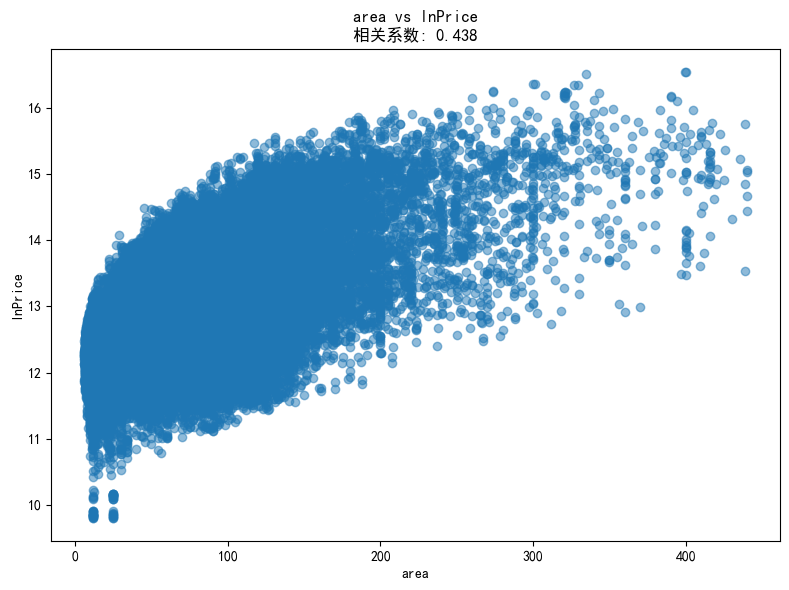

In [33]:
# 3.3 探究训练集自变量与lnPrice的关系
print("\n=== 3.3 探究训练集自变量与lnPrice的关系 ===")

# 计算所有数值变量与lnPrice的相关系数
numeric_cols = final_train_df.select_dtypes(include=[np.number]).columns.tolist()
correlations = final_train_df[numeric_cols].corr()['lnPrice'].abs().sort_values(ascending=False)

print("\n训练集变量与lnPrice的相关系数（绝对值前10）:")
for var, corr in correlations.head(11).items():
    if var != 'lnPrice':
        print(f"{var}: {corr:.3f}")

# 选择与lnPrice相关性最高的几个变量
top_vars = correlations[1:6].index.tolist()
print(f"\n与lnPrice相关性最高的变量: {top_vars}")

# 绘制area与lnPrice的关系（最重要的变量）
if 'area' in final_train_df.columns:
    plt.figure(figsize=(8, 6))
    plt.scatter(final_train_df['area'], final_train_df['lnPrice'], alpha=0.5)
    plt.xlabel('area')
    plt.ylabel('lnPrice')
    plt.title(f'area vs lnPrice\n相关系数: {correlations["area"]:.3f}')
    plt.tight_layout()
    plt.show()

In [34]:
# 4. 保存最终数据集
print("\n=== 4. 保存最终数据集 ===")

# 保存训练集
train_output_file = 'rent_price_train_dataset.csv'
final_train_df.to_csv(train_output_file, index=False, encoding='utf-8-sig')
print(f"训练集已保存为: {train_output_file}")
print(f"训练集最终形状: {final_train_df.shape}")

# 保存测试集（之前已保存，这里再次确认）
test_output_file = 'rent_price_test_dataset.csv'
final_test_df.to_csv(test_output_file, index=False, encoding='utf-8-sig')
print(f"测试集已保存为: {test_output_file}")
print(f"测试集最终形状: {final_test_df.shape}")

print("\n✅ 所有数据处理完成！")


=== 4. 保存最终数据集 ===
训练集已保存为: rent_price_train_dataset.csv
训练集最终形状: (98899, 82)
测试集已保存为: rent_price_test_dataset.csv
测试集最终形状: (9773, 81)

✅ 所有数据处理完成！
